# Phase 2 — StreamFlix Exploratory Data Analysis

Ten required EDA visualisations are included, with observations written in plain language.

## 1. Load data

In [1]:
import pandas as pd, numpy as np
from pathlib import Path

DATA_DIR = Path(".")  # change if the CSV files are stored elsewhere

subscribers = pd.read_csv(DATA_DIR/"subscribers.csv", parse_dates=["signup_date","churn_date"])
titles = pd.read_csv(DATA_DIR/"titles.csv", parse_dates=["date_added","license_expiry"])
watch_history = pd.read_csv(DATA_DIR/"watch_history.csv", parse_dates=["watch_date"])
ratings = pd.read_csv(DATA_DIR/"ratings.csv", parse_dates=["rating_date"])
reviews = pd.read_csv(DATA_DIR/"reviews.csv", parse_dates=["review_date"])
watchlist = pd.read_csv(DATA_DIR/"watchlist.csv", parse_dates=["added_date"])

tables = {
    "subscribers": subscribers,
    "titles": titles,
    "watch_history": watch_history,
    "ratings": ratings,
    "reviews": reviews,
    "watchlist": watchlist
}

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
wh = watch_history.copy()
wh['month']=wh.watch_date.dt.to_period('M').astype(str)
merged = wh.merge(titles[['title_id','title_name','type','primary_genre','country','language','is_original']], on='title_id', how='left')

## 2. Monthly viewing volume

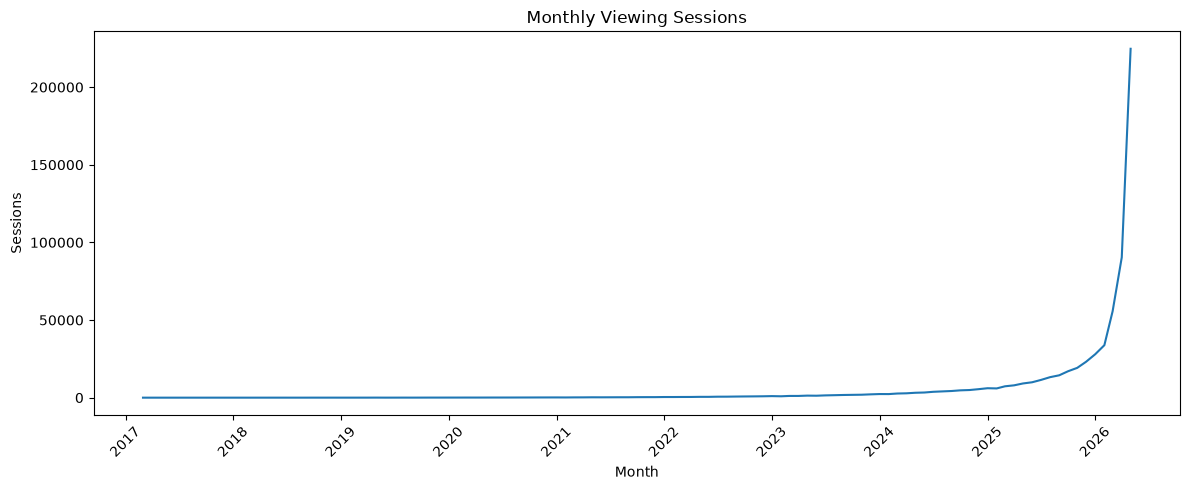

In [3]:
monthly = wh.groupby('month').size().reset_index(name='sessions')
plt.figure(figsize=(12,5)); plt.plot(pd.to_datetime(monthly.month),monthly.sessions); plt.title('Monthly Viewing Sessions'); plt.xlabel('Month'); plt.ylabel('Sessions'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Observation: The supplied data shows a sharp increase in viewing volume toward the latest months, with May 2026 the busiest month.

## 3. Monthly watch hours

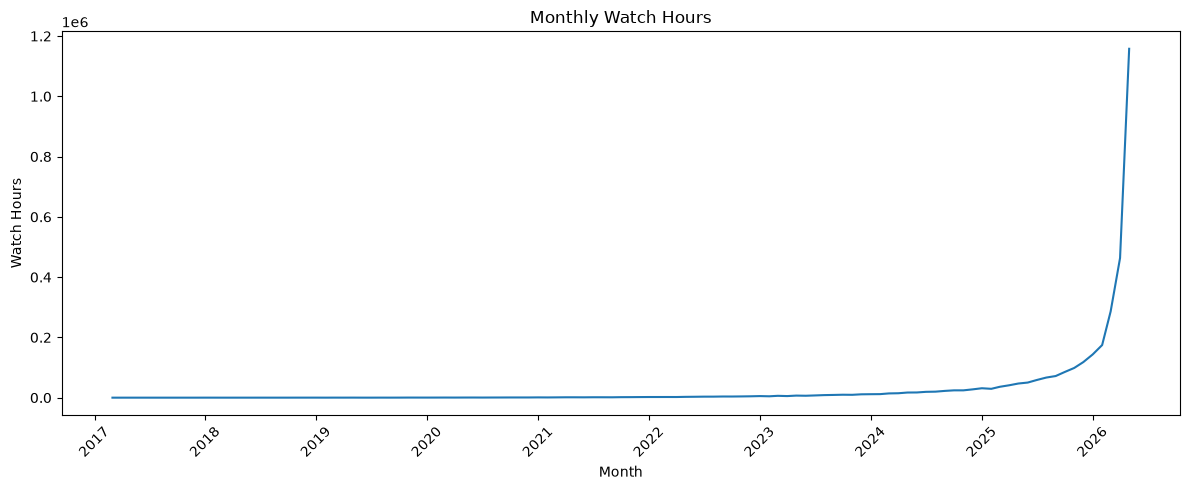

In [4]:
monthly_h = wh.groupby('month').watch_duration_min.sum().div(60).reset_index(name='watch_hours')
plt.figure(figsize=(12,5)); plt.plot(pd.to_datetime(monthly_h.month),monthly_h.watch_hours); plt.title('Monthly Watch Hours'); plt.xlabel('Month'); plt.ylabel('Watch Hours'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Observation: Watch hours follow the same broad upward pattern as sessions, with the highest observed month at the end of the available timeline.

## 4. Genre-wise watch hours

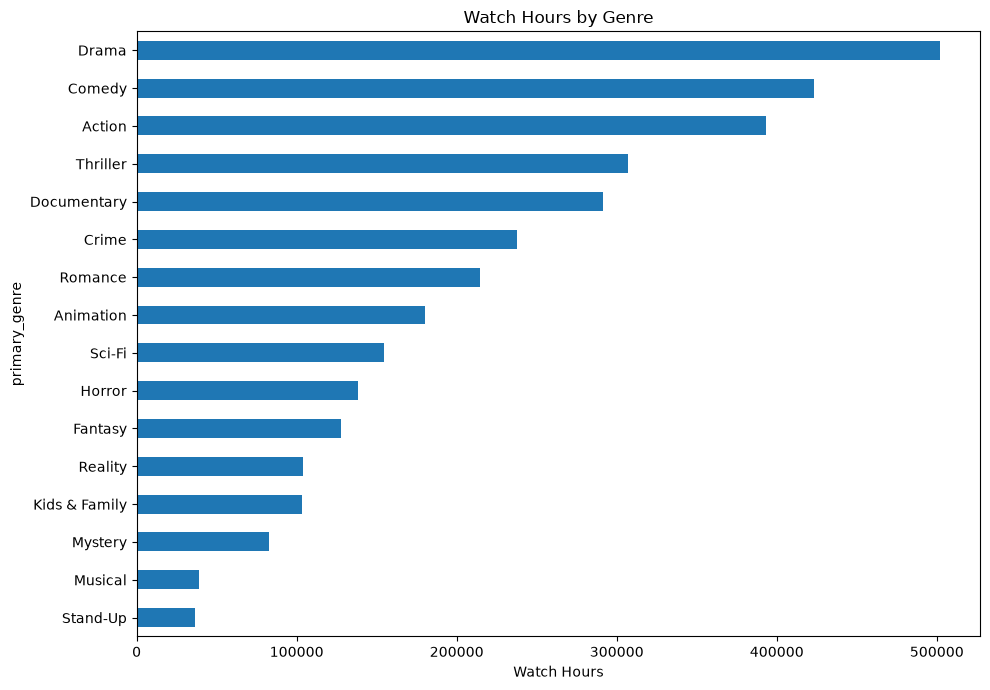

In [5]:
g=merged.groupby('primary_genre').watch_duration_min.sum().div(60).sort_values(ascending=True)
plt.figure(figsize=(10,7)); g.plot(kind='barh'); plt.title('Watch Hours by Genre'); plt.xlabel('Watch Hours'); plt.tight_layout(); plt.show()

Observation: Drama leads watch time, followed by Comedy and Action.

## 5. Movies vs TV Shows

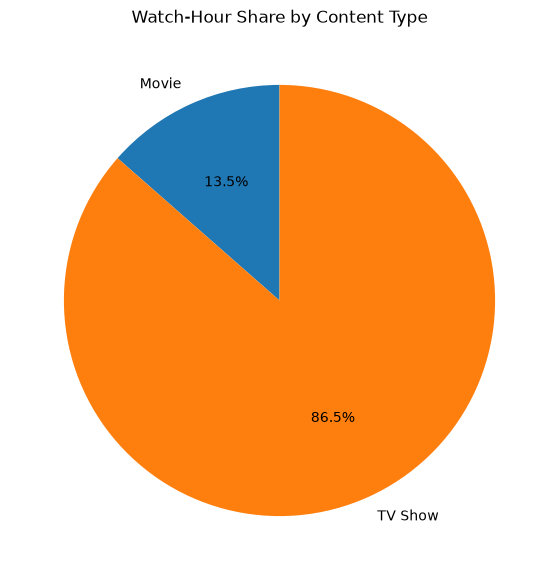

In [6]:
t=merged.groupby('type').watch_duration_min.sum().div(60)
plt.figure(figsize=(7,7)); plt.pie(t,labels=t.index,autopct='%1.1f%%',startangle=90); plt.title('Watch-Hour Share by Content Type'); plt.show()

Observation: TV Shows account for the large majority of watch hours.

## 6. Top 10 countries

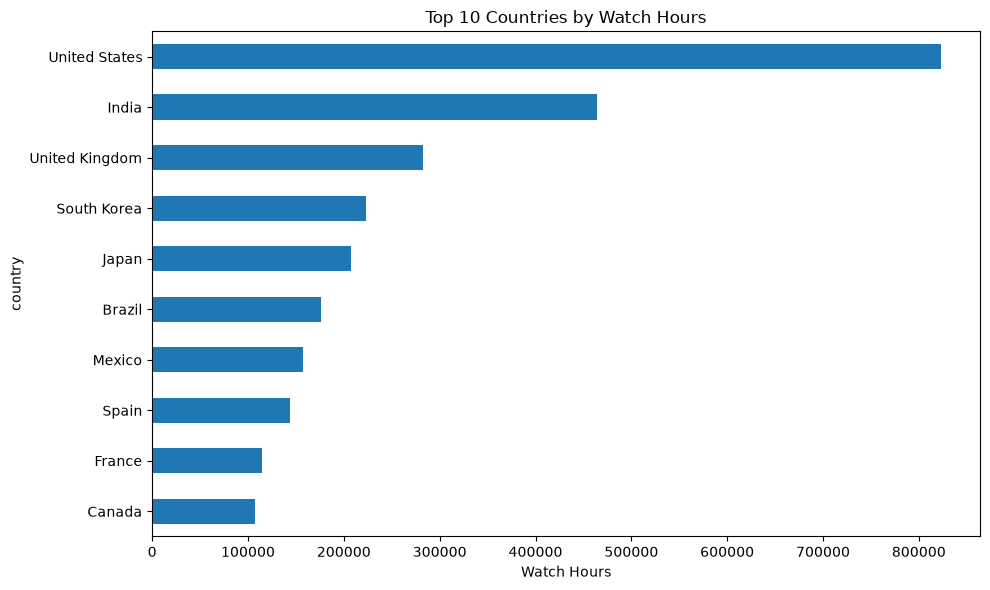

In [7]:
c=merged.groupby('country').watch_duration_min.sum().div(60).sort_values(ascending=False).head(10).sort_values()
plt.figure(figsize=(10,6)); c.plot(kind='barh'); plt.title('Top 10 Countries by Watch Hours'); plt.xlabel('Watch Hours'); plt.tight_layout(); plt.show()

Observation: The United States is the largest watch-hours market, followed by India and the United Kingdom.

## 7. Subscriber plan distribution

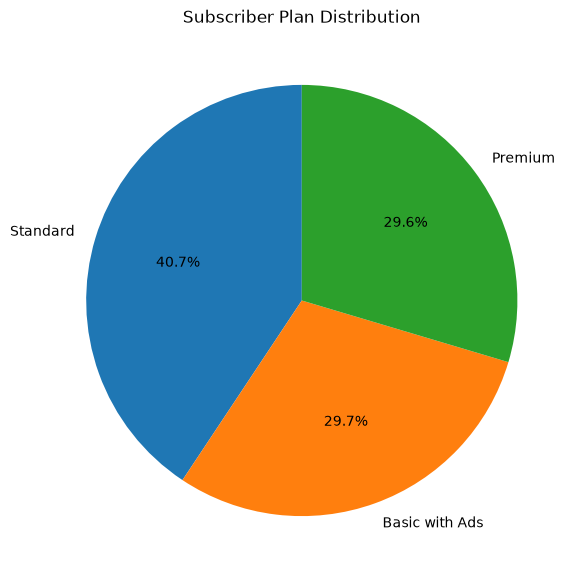

In [8]:
p=subscribers.plan_type.value_counts()
plt.figure(figsize=(7,7)); plt.pie(p,labels=p.index,autopct='%1.1f%%',startangle=90); plt.title('Subscriber Plan Distribution'); plt.show()

Observation: Standard is the largest subscriber plan, with Basic with Ads and Premium at similar scale.

## 8. Device usage

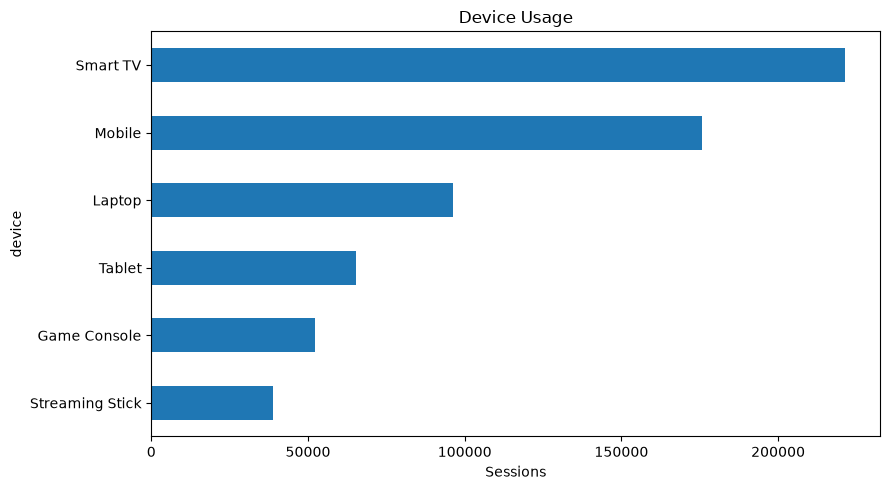

In [9]:
d=wh.device.value_counts().sort_values()
plt.figure(figsize=(9,5)); d.plot(kind='barh'); plt.title('Device Usage'); plt.xlabel('Sessions'); plt.tight_layout(); plt.show()

Observation: Smart TV is the most-used device, followed by Mobile.

## 9. Age distribution

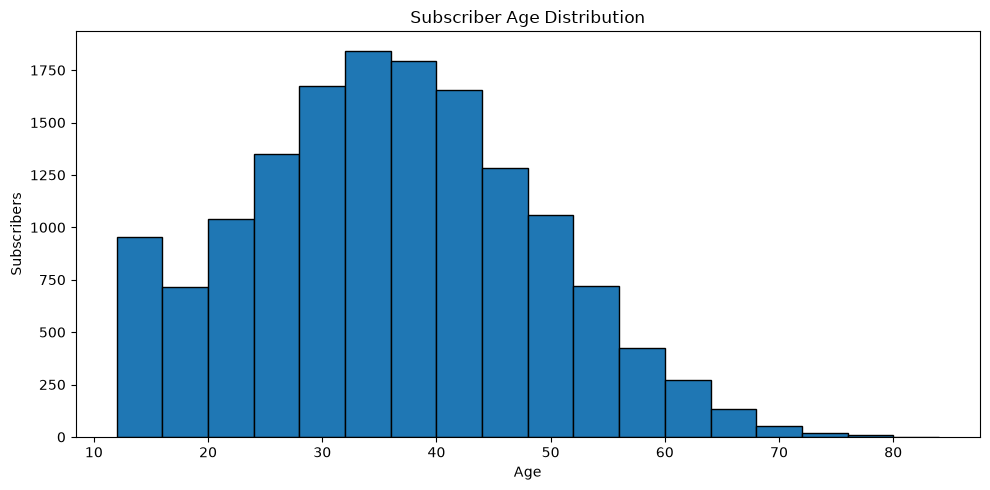

In [10]:
plt.figure(figsize=(10,5)); plt.hist(subscribers.age,bins=range(12,87,4),edgecolor='black'); plt.title('Subscriber Age Distribution'); plt.xlabel('Age'); plt.ylabel('Subscribers'); plt.tight_layout(); plt.show()

Observation: The subscriber base is concentrated around ages 25–44.

## 10. Completion rate by genre

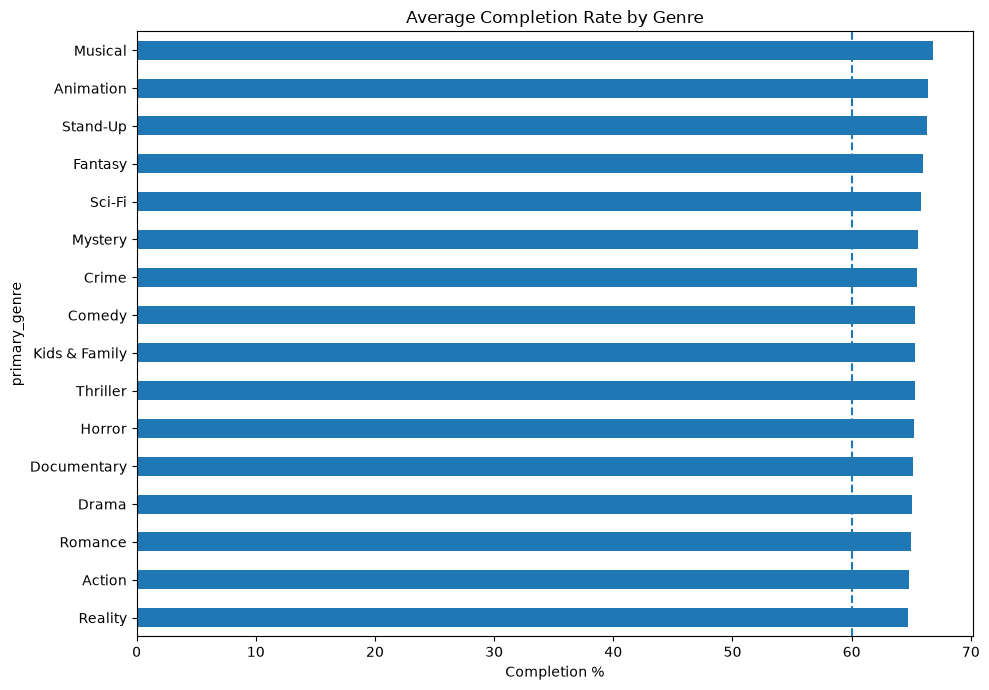

In [11]:
cg=merged.groupby('primary_genre').completion_pct.mean().sort_values()
plt.figure(figsize=(10,7)); cg.plot(kind='barh'); plt.axvline(60,linestyle='--'); plt.title('Average Completion Rate by Genre'); plt.xlabel('Completion %'); plt.tight_layout(); plt.show()

Observation: All genres average above the 60% completion target; Musical has the highest average completion in the supplied data.

## 11. Review sentiment

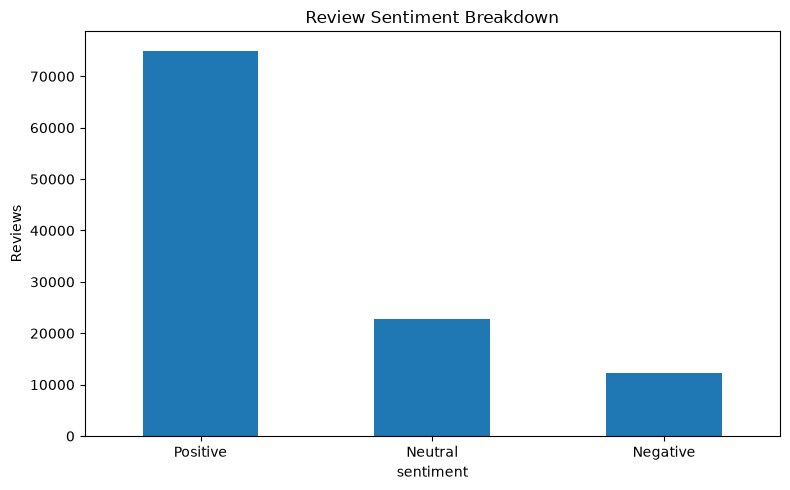

In [12]:
s=reviews.sentiment.value_counts().reindex(['Positive','Neutral','Negative']).fillna(0)
plt.figure(figsize=(8,5)); s.plot(kind='bar'); plt.title('Review Sentiment Breakdown'); plt.ylabel('Reviews'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Observation: Positive reviews dominate the review dataset, indicating generally favorable customer sentiment.

## Save all charts
The project deliverable also asks for PNG copies. The complete project package includes the generated PNG files.